# 온라인 쇼핑 세션 군집화 (K-Means) - 행동 기반 방문자 세분화

지도학습 3종(Decision Tree / Random Forest / KNN)이 **"이 세션이 구매할까?"** 를 예측했다면,
이 노트북은 비지도 학습으로 **"방문자가 행동상 어떤 유형으로 나뉘는가, 유형별 구매율은 어떻게 다른가"** 를 분석한다.

핵심 원칙:
1. **`Revenue`(구매 여부)는 군집 학습에 사용하지 않는다.** 순수하게 행동 변수만으로 군집을 만든 뒤,
   사후에 군집별 실제 구매율을 붙여 해석/검증한다. (비지도의 정의를 지킴)
2. **KNN 전처리 입력을 그대로 재사용한다.** K-Means도 유클리드 거리 기반이라 KNN과 요구사항이 같다
   (ID 변수·Month 제외, 11개 수치 컬럼, `PageValues` 누수 변수 제외).
3. 군집은 기술적(descriptive) 분석이므로 train/test를 합친 전체 세션(중복 제거 후 12,205건)에 적용한다.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path  # OS에 상관없이 파일 경로를 다루는 표준 도구

# scikit-learn: 군집화와 평가에 필요한 도구들
from sklearn.preprocessing import StandardScaler       # 변수 스케일을 평균0·표준편차1로 표준화
from sklearn.cluster import KMeans                      # K-Means 군집 알고리즘
from sklearn.decomposition import PCA                   # 차원 축소(11차원 → 2차원 시각화)
from sklearn.model_selection import train_test_split    # train/test 분할(일반화 검증용)
from sklearn.metrics import (                           # 군집 품질·일치도 평가 지표 모음
    silhouette_score, silhouette_samples,              # 실루엣: 군집이 얼마나 또렷한가
    davies_bouldin_score, calinski_harabasz_score,     # 또 다른 내부 평가 지표
    adjusted_rand_score, normalized_mutual_info_score,  # 두 군집/라벨의 일치도
    homogeneity_completeness_v_measure)
from scipy.stats import chi2_contingency               # 카이제곱 독립성 검정(범주형 통계)
from scipy.optimize import linear_sum_assignment       # 최적 1:1 매칭(군집 색 일관성 맞추기)
import itertools                                        # 조합(시드 쌍 만들기)에 사용

# ── 전역 설정 ────────────────────────────────────────────────────
# 난수 고정값: 실행마다 같은 결과가 나오도록 모든 무작위 과정에 동일 시드를 쓴다.
RANDOM_STATE = 42

# 출력 보기 좋게: 표 컬럼 다 보이게, 너비 넓게, 기본 그래프 크기 지정
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (8, 4.5)

## 1. 데이터 로드

KNN 전처리 산출물(`models/knn/csv/`)을 재사용한다. 이 CSV는 `log1p`/스케일/SMOTE 적용 **전** 데이터라
군집용 전처리(log1p → 표준화)를 이 노트북에서 직접 수행한다. train/test를 모두 합쳐 전체 세션을 군집한다.


In [ ]:
# ── 데이터 로드 ──────────────────────────────────────────────────
X_train = pd.read_csv('csv/X_train_knn.csv', encoding = 'utf-8')
X_test = pd.read_csv('csv/X_test_knn.csv', encoding = 'utf-8')
y_train = pd.read_csv('csv/y_train_knn.csv', encoding = 'utf-8')['Revenue']
y_test = pd.read_csv('csv/y_test_knn.csv', encoding = 'utf-8')['Revenue']

# 군집화는 '예측'이 아니라 '전체 구조 파악'이 목적이므로 train/test를 다시 하나로 합친다.
X = pd.concat([X_train, X_test], ignore_index = True)
# y(구매여부)는 군집 학습엔 절대 쓰지 않고, 나중에 '군집별 실제 구매율'을 볼 때만 참고한다.
y = pd.concat([y_train, y_test], ignore_index = True)

print(f'전체 세션   : {X.shape},  실제 구매율(참고용): {y.mean():.4f}')
print(f'사용 변수({X.shape[1]}개): {list(X.columns)}')
X.head()

전체 세션   : (12205, 11),  실제 구매율(참고용): 0.1563
사용 변수(11개): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'is_new_visitor']


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend,is_new_visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,0.0,0,0
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,0.0,0,1
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.8,0,0
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.0,1,1
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.0,0,0


## 2. 군집용 전처리 (log1p → 표준화)

K-Means는 거리 기반이라 스케일에 민감하다. 두 단계를 거친다.

1. **`log1p`** — 페이지 수/체류 시간/이탈률 등 강한 우편향 변수의 큰 값이 거리를 지배하지 않도록 압축.
2. **`StandardScaler`** — 모든 변수를 평균 0/표준편차 1로 맞춰 동등한 비중으로 거리 계산.

`Revenue`는 여기에 포함되지 않는다(비지도 유지). `Weekend`, `is_new_visitor`는 이미 0/1이라 log는 생략한다.


In [3]:
# ── 전처리 1: 한쪽으로 치우친 변수 펴기 (log 변환) ────────────────
# 페이지 수·체류시간 등은 대부분 작고 일부만 아주 큰 '오른쪽 꼬리' 분포다.
# 이 큰 값들이 거리 계산을 지배하지 않도록 log를 씌워 분포를 완만하게 만든다.
LOG_COLS = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
]
# Weekend·is_new_visitor는 이미 0/1 값이라 로그가 의미 없어 제외했다.
X_log = X.copy()
X_log[LOG_COLS] = np.log1p(X_log[LOG_COLS])

# ── 전처리 2: 변수 단위 맞추기 (표준화) ──────────────────────────
# StandardScaler로 모든 변수를 평균 0·표준편차 1로 맞춰 같은 비중으로 거리에 반영되게 한다.
scaler = StandardScaler()
Z = scaler.fit_transform(X_log)   # Z: 표준화된 11차원 데이터(군집의 실제 입력)

print(f'스케일링 완료: {Z.shape}')
print('변환 후 각 컬럼 평균(≈0)/표준편차(≈1) 확인:')
print(pd.DataFrame(Z, columns = X.columns).describe().loc[['mean', 'std']].round(3))

스케일링 완료: (12205, 11)
변환 후 각 컬럼 평균(≈0)/표준편차(≈1) 확인:
      Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  SpecialDay  Weekend  is_new_visitor
mean            -0.0                      0.0            0.0                     0.0            -0.0                     -0.0          0.0       -0.0        -0.0      0.0             0.0
std              1.0                      1.0            1.0                     1.0             1.0                      1.0          1.0        1.0         1.0      1.0             1.0


## 3. 군집 개수 K 선택 — 엘보우 + 실루엣

K는 "정답"이 없으므로 두 지표를 함께 본다.

- **엘보우(inertia)**: 군집 내 거리 제곱합. 꺾이는 지점(추가 군집의 이득이 줄어드는 곳)을 찾는다.
- **실루엣 계수**: 군집이 얼마나 뚜렷하게 분리됐는지(−1~1, 높을수록 좋음).

자동 argmax로 기계적으로 고르지 않고, 두 지표 + **해석 가능성**을 함께 근거로 K를 정한다.


 K     inertia  silhouette
 2 102581.6096      0.2328
 3  80645.5998      0.3225
 4  65272.1159      0.2753
 5  56185.6057      0.2993
 6  48222.5088      0.3218
 7  43893.8020      0.3274
 8  40877.3224      0.2944
 9  38527.4336      0.2914
10  36418.7173      0.3118


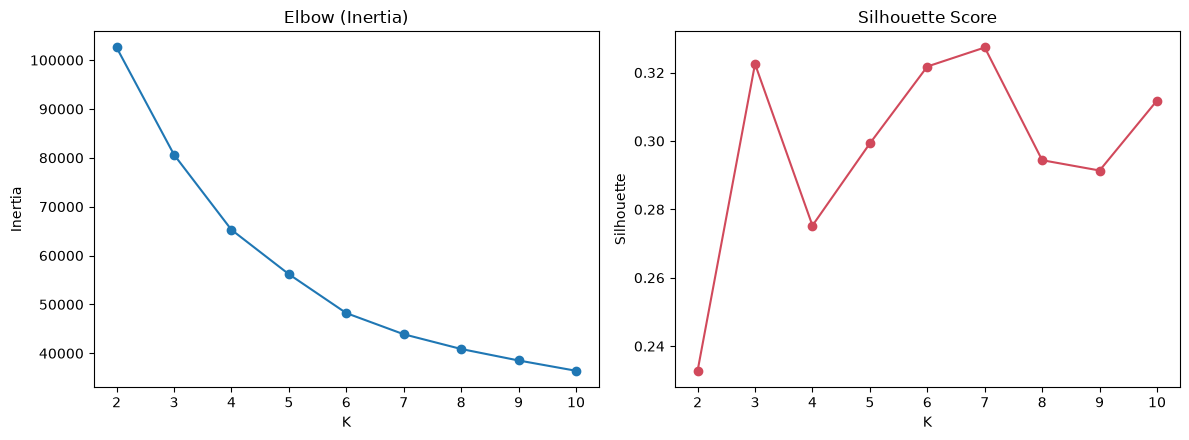

In [ ]:
# ── 적정 군집 수(K) 탐색: 엘보우 + 실루엣 ─────────────────────────
# K-Means는 몇 개로 나눌지(K) 정답이 없으므로 K를 바꿔가며 두 지표를 보고 고른다.
K_CANDIDATES = list(range(2, 11))   # 시험할 K 후보(군집 2개 ~ 10개)
SILHOUETTE_SAMPLE = 4000            # 실루엣은 표본이 크면 느려서 4,000개만 뽑아 근사(속도용)

sweep = []
for k in K_CANDIDATES:
    # n_init = 10: 무작위 초기 중심을 10번 다르게 시도해 그중 가장 좋은 결과를 채택
    km = KMeans(n_clusters = k, random_state = RANDOM_STATE, n_init = 10)
    labels = km.fit_predict(Z)
    # inertia_ : 군집내 거리 제곱합(작을수록 조밀) / 실루엣: -1~1(클수록 또렷)
    sil = silhouette_score(Z, labels, sample_size = SILHOUETTE_SAMPLE, random_state = RANDOM_STATE)
    sweep.append({'K': k, 'inertia': km.inertia_, 'silhouette': sil})

sweep_df = pd.DataFrame(sweep)
print(sweep_df.round(4).to_string(index = False))

# 두 지표를 나란히 그려 '꺾이는 지점(엘보우)'과 '실루엣 정점'을 함께 확인한다.
fig, axes = plt.subplots(1, 2, figsize = (12, 4.5))
axes[0].plot(sweep_df['K'], sweep_df['inertia'], marker = 'o')
axes[0].set_title('Elbow (Inertia)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(sweep_df['K'], sweep_df['silhouette'], marker = 'o', color = '#d1495b')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

### K 선택 근거

- **엘보우**: inertia가 K=2→3에서 가장 크게 꺾인 뒤 완만해진다(굴절점 ≈ 3).
- **실루엣**: K=3,7 에서 또렷한 국소 최댓값(≈0.32)을 가진다. 단 7가지로 나눌 경우 분석이 복잡해진다.  
때문에
→ **K=3** 채택.


In [5]:
# ── 최종 군집 학습 (K=3) ─────────────────────────────────────────
# 3개일 때 '즉시이탈 / 일반탐색 / 고관여'로 깔끔하게 해석할수 있다.
BEST_K = 3

kmeans = KMeans(n_clusters = BEST_K, random_state = RANDOM_STATE, n_init = 10)
cluster_labels = kmeans.fit_predict(Z)   # 각 세션이 어느 군집(0/1/2)에 속하는지

# 해석용 표: 원본 변수 + 군집번호 + (참고용)구매여부를 한 표에 모은다.
profile = X.copy()
profile['cluster'] = cluster_labels
profile['Revenue'] = y.values # 학습엔 안 쓰고 사후 해석에만 사용

print(f'최종 군집 (K={BEST_K})')
print(profile['cluster'].value_counts().sort_index())

최종 군집 (K=3)
cluster
0    8988
1    2313
2     904
Name: count, dtype: int64


## 4. 군집 프로파일 — 각 유형은 어떤 방문자인가

원래 단위(역변환 불필요, 평균은 원본 스케일로 해석)로 군집별 평균을 본다.
어떤 행동 변수가 군집을 가르는지 확인한다.


In [ ]:
# ── 군집별 프로파일: 어떤 행동의 군집인가 ─────────────────────────
# 군집마다 주요 변수의 평균을 구해 '이 군집은 어떤 방문자인지' 특징을 읽는다.
profile_table = profile.groupby('cluster').agg(
    size = ('Revenue', 'size'),                                     # 군집 크기(세션 수)
    purchase_rate = ('Revenue', 'mean'),                            # 군집별 실제 구매율(0~1)
    ProductRelated = ('ProductRelated', 'mean'),                    # 상품 페이지 조회 수
    ProductRelated_Duration = ('ProductRelated_Duration', 'mean'),  # 상품 페이지 체류시간
    Administrative = ('Administrative', 'mean'),                    # 관리(계정 등) 페이지 수
    BounceRates = ('BounceRates', 'mean'),                          # 첫 페이지에서 바로 이탈한 비율
    ExitRates = ('ExitRates', 'mean'),                              # 페이지를 떠난 비율
    is_new_visitor = ('is_new_visitor', 'mean'),                    # 신규 방문자 비율
    Weekend = ('Weekend', 'mean'),                                  # 주말 세션 비율
)
profile_table['size_pct'] = profile_table['size'] / profile_table['size'].sum()  # 전체 대비 비중
print(profile_table.round(3).to_string())

         size  purchase_rate  ProductRelated  ProductRelated_Duration  Administrative  BounceRates  ExitRates  is_new_visitor  Weekend  size_pct
cluster                                                                                                                                         
0        8988          0.150          26.305                  964.478           1.856        0.009      0.033           0.159    0.229     0.736
1        2313          0.240          65.822                 2604.715           5.113        0.007      0.022           0.102    0.275     0.190
2         904          0.004           2.705                   41.798           0.043        0.163      0.179           0.033    0.183     0.074


### 군집 해석 (네이밍)

| cluster | 규모 | 구매율 | 행동 특징 | 라벨 |
|---|---:|---:|---|---|
| 즉시 이탈형 | ~7% | **~0.4%** | 상품 페이지 ~3개·체류 ~40초, BounceRate/ExitRate 매우 높음 | **Bouncers** |
| 일반 탐색형 | ~74% | ~15% | 평균적 탐색(상품 ~26페이지), 전체의 다수 | **Browsers** |
| 고관여형 | ~19% | **~24%** | 상품 ~66페이지·체류 ~2,600초, Administrative 페이지도 많음 | **Engaged buyers** |

핵심 인사이트: **세션 깊이(ProductRelated 페이지 수·체류 시간)가 깊어질수록 구매율이 단조 상승**한다
(0.4% → 15% → 24%). 이탈률(Bounce/Exit)이 높은 군집은 거의 구매하지 않는다.


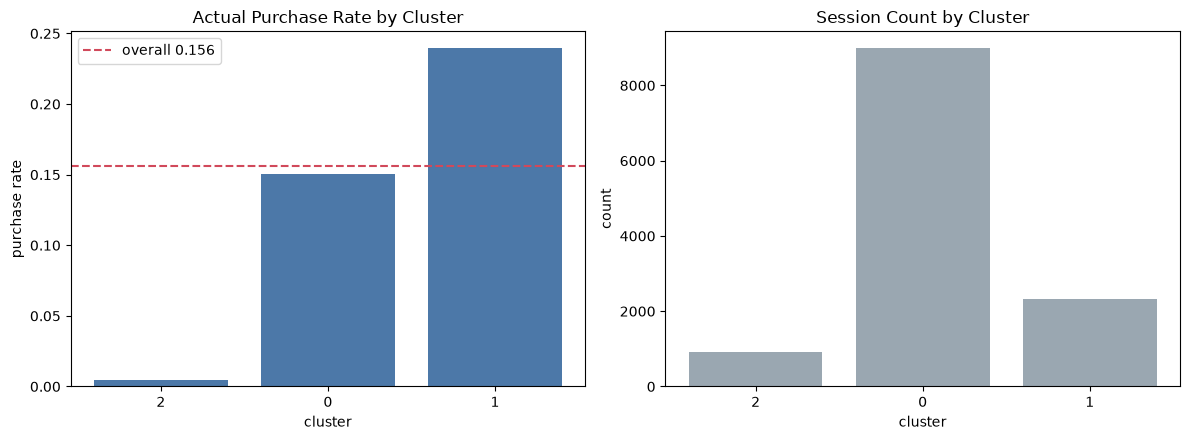

In [7]:
# ── 군집별 구매율·규모 시각화 ────────────────────────────────────
# 군집을 구매율 오름차순으로 정렬해, 행동 유형에 따라 구매율이 단조 증가하는지 본다.
order = profile_table.sort_values('purchase_rate').index

fig, axes = plt.subplots(1, 2, figsize = (12, 4.5))

# (좌) 군집별 구매율 — 점선은 전체 평균 구매율(기준선)
axes[0].bar(order.astype(str), profile_table.loc[order, 'purchase_rate'], color = '#4c78a8')
axes[0].axhline(y.mean(), color = '#d1495b', linestyle = '--', label = f'overall {y.mean():.3f}')
axes[0].set_title('Actual Purchase Rate by Cluster')
axes[0].set_xlabel('cluster'); axes[0].set_ylabel('purchase rate'); axes[0].legend()

# (우) 군집별 세션 수 — 어느 유형이 다수/소수인지
axes[1].bar(order.astype(str), profile_table.loc[order, 'size'], color = '#9aa7b1')
axes[1].set_title('Session Count by Cluster')
axes[1].set_xlabel('cluster'); axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()

## 5. 군집 × 범주형 교차 분석

행동 군집이 `is_new_visitor`, `Weekend` 같은 범주형 신호와 어떻게 겹치는지 본다.


In [ ]:
# ── 교차분석: 군집과 범주형 신호의 관계 ──────────────────────────
# 행동으로 나뉜 군집이 '신규/재방문', '주중/주말' 같은 범주형 변수와
# 얼마나 겹치는지 비율로 본다. normalize='index'는 각 군집(행) 안에서
# 비율의 합이 1이 되게 정규화해 군집끼리 비교할 수 있게 한다.ㅈㅈ
cross_new = pd.crosstab(profile['cluster'], profile['is_new_visitor'], normalize = 'index').round(3)
cross_new.columns = ['returning(0)', 'new(1)']
print('군집별 신규/재방문 비율')
print(cross_new.to_string())

cross_wk = pd.crosstab(profile['cluster'], profile['Weekend'], normalize = 'index').round(3)
cross_wk.columns = ['weekday(0)', 'weekend(1)']
print('\n군집별 주중/주말 비율')
print(cross_wk.to_string())

군집별 신규/재방문 비율
         returning(0)  new(1)
cluster                      
0               0.841   0.159
1               0.898   0.102
2               0.967   0.033

군집별 주중/주말 비율
         weekday(0)  weekend(1)
cluster                        
0             0.771       0.229
1             0.725       0.275
2             0.817       0.183


### 교차분석 해석 — 범주형 신호는 군집을 가르는 주축이 아니다

- **세 군집 모두 재방문자가 절대다수(84~97%)** 다. 즉 `is_new_visitor`·`Weekend` 같은 범주형 변수는
  군집을 만든 핵심 축이 **아니다**. 군집은 어디까지나 세션 깊이(상품 페이지 수·체류 시간) 같은
  **연속형 행동 변수**로 갈렸고, 범주형은 약한 부가 신호일 뿐이다(군집 간 차이 ±5%p 수준).
- 그래도 읽히는 경향:
  - **신규 방문자 비율**: 일반 탐색(15.9%) > 고관여(10.2%) > **즉시 이탈(3.3%)**. 즉시 이탈 군집이
    거의 전부 재방문자라는 점이 눈에 띈다 — 습관적으로 잠깐 들렀다 나가는 재방문 세션에 가깝다.
    오히려 신규 방문자는 (즉시 이탈보다) 일반 탐색에 더 많이 분포한다.
  - **주말 비율**: 고관여(27.5%)에서 가장 높고 즉시 이탈(18.3%)에서 가장 낮다. 시간 여유가 있는
    주말 세션이 깊은 탐색·구매로 이어질 여지를 시사하지만, 차이 폭이 작아 결정적 변수는 아니다.
- 함의: 신규/주말 같은 **맥락 변수보다 세션 내 행동(관여 깊이)이 구매 성향을 훨씬 강하게 가른다**.
  타깃팅은 "언제 왔는가"보다 "세션에서 무엇을 했는가"를 기준으로 잡는 편이 낫다.


## 6. PCA 2D 시각화

11차원 군집을 2개 주성분으로 투영해 분리 양상을 눈으로 확인한다.
(시각화 전용 — 군집 자체는 11차원 원공간에서 수행됨)


### PCA 시각화 해석

- 두 주성분이 전체 분산의 **54%만** 설명한다. 나머지 ~46%의 구조는 2D 평면에 나타나지 않으므로,
  그림에서 군집 경계가 일부 겹쳐 보이는 것은 **정보 손실 탓이지 군집이 나빠서가 아니다**
  (실제 군집은 11차원 원공간에서 수행됨, 실루엣 ≈ 0.32).
- 그럼에도 패턴은 또렷하다: **즉시 이탈(Bouncers) 군집은 한쪽 끝으로 뚜렷이 분리**되고,
  **고관여(Engaged) 군집은 반대쪽 끝으로 뻗는다**. 즉 PC1 축이 사실상 *'세션 깊이·관여도'* 축 역할을 한다.
- 다수인 **일반 탐색(Browsers) 군집이 중앙에 넓게 퍼져 고관여 쪽으로 연속적으로 이어진다**.
  이는 관여도가 끊어진 범주가 아니라 **연속 스펙트럼**이며, K-Means가 그 스펙트럼을 3구간으로 끊었음을 보여준다.
  실무적으로는 일반 탐색과 고관여의 경계 근처 세션이 전환 유도(넛지)의 핵심 타깃이다.


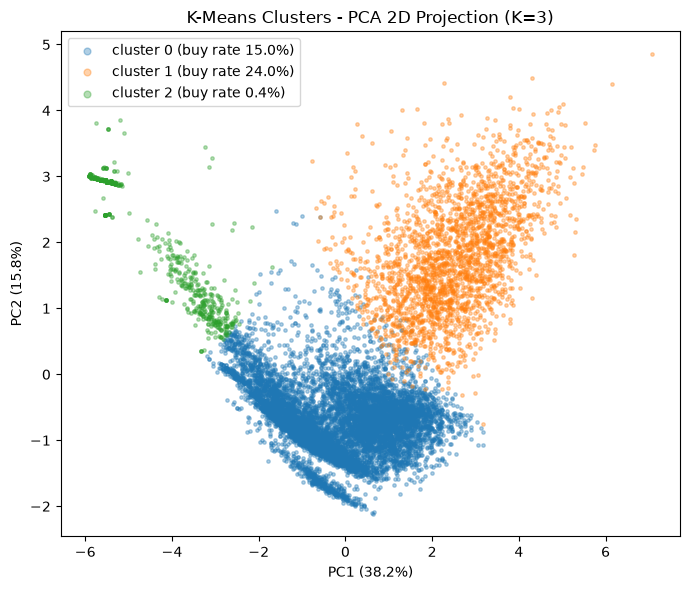

2개 주성분 누적 설명 분산: 54.0%


In [9]:
# ── PCA 2D 시각화 ────────────────────────────────────────────────
# 11차원 군집을 눈으로 보려면 2차원으로 줄여야 한다. PCA는 데이터의
# 분산(정보)을 가장 많이 담는 두 축(주성분)을 찾아 그 평면에 투영한다.
# 주의: 군집 자체는 11차원에서 수행했고, 여기서는 '보기용'으로만 2D로 누른다.
pca = PCA(n_components = 2, random_state = RANDOM_STATE)
coords = pca.fit_transform(Z)   # coords: 각 세션의 2D 좌표

plt.figure(figsize = (7, 6))
for c in sorted(profile['cluster'].unique()):
    m = profile['cluster'] == c    # 군집 c에 속한 점만 골라 그린다
    plt.scatter(coords[m, 0], coords[m, 1], s = 6, alpha = 0.35,
                label = f'cluster {c} (buy rate {profile_table.loc[c, "purchase_rate"]:.1%})')
plt.title(f'K-Means Clusters - PCA 2D Projection (K={BEST_K})')
# 축 라벨에 각 주성분이 설명하는 분산 비율을 표시(두 축 합이 클수록 2D가 원공간을 잘 대변)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(markerscale = 2)
plt.tight_layout()
plt.show()

print(f'2개 주성분 누적 설명 분산: {pca.explained_variance_ratio_.sum():.1%}')

## 7. 군집 성능 평가 — 내부지표 · 외부지표 · 안정성

지도학습과 달리 군집화에는 단일 '정확도'가 없다. 군집 품질은 세 갈래로 나눠 평가한다.

- **내부지표(Internal)** — 정답 라벨 없이 군집 구조 자체의 품질(응집도·분리도)을 측정.
  실루엣, Davies–Bouldin, Calinski–Harabasz, inertia.
- **외부지표(External)** — 외부 라벨(여기서는 *학습에 쓰지 않은* `Revenue`)과 군집이 얼마나 일치하는지.
  ARI, NMI, homogeneity/completeness/V-measure, purity.
- **안정성(Stability)** — 초기화 시드·데이터 표본을 바꿔도 같은 군집이 재현되는지.
  군집 해가 우연한 산물이 아님을 보증한다.

세 지표를 함께 봐야 "군집이 뚜렷한가 / 의미 있는 신호와 연결되는가 / 재현 가능한가"를 모두 답할 수 있다.

### 지표 읽는 기준 — 어디서 쓰고, 어느 수준이 좋은가

본격적으로 보기 전에, 각 지표가 *원래 어떤 분석에서 쓰이고* *어느 수준이면 좋은지* 부터 정리한다.
(군집화 지표는 절대 정답이 드물어 "기준"은 통용되는 경험칙임.)

| 지표 | 원래 쓰는 분석 | 범위 · 방향 | "좋음" 기준(경험칙) | 이 분석 값 → 판정 |
|---|---|---|---|---|
| **Silhouette** | 군집 품질·최적 K 선택 | −1 ~ 1, 높을수록 | 0.7+ 강함 / 0.5+ 무난 / 0.25~0.5 약하나 존재 / 0.25↓ 구조 없음 (Kaufman·Rousseeuw) | **0.32** → 약하지만 분명(행동데이터 정상) |
| **Davies–Bouldin** | 군집 평가·K 비교 | 0 ~ ∞, 낮을수록 | 절대기준 없음 · 1 부근이면 양호 · K끼리 최소값 | **1.16** → 양호 |
| **Calinski–Harabasz** | 군집 평가·K 선택 | 0 ~ ∞, 높을수록 | 절대기준 없음 · 같은 데이터에서 K별 비교해 최대값 | **4,056** → K비교용(K=3 우수) |
| **Inertia (WCSS)** | K-Means 목적함수·엘보우법 | 0 ~ ∞, 낮을수록 | 절대 성능 아님(K↑면 무조건↓) · 꺾이는 점만 본다 | 엘보우 K=3 |
| **ARI** (재현성·복원) | 같은 데이터를 다시 군집했을 때 일치(정답 구조 복원) | −0.5 ~ 1, 우연=0 | 0.9+ 탁월 / 0.8~0.9 좋음 / 0.65~0.8 보통 / 0.65↓ 약함 (Steinley 2004) | 시드 **1.00** · 부트스트랩 **0.998** → 탁월(재현성 높음) |
| **ARI·NMI** (외부 라벨 일치도) | 군집이 외부 라벨(Revenue)과 얼마나 겹치나 | ARI −0.5~1 · NMI 0~1, 우연·독립=0 | 비지도에선 낮아도 정상(군집 수 ≠ 라벨 수면 0에 가까움) | vs Revenue ARI **0.01** · NMI **0.03** → 거의 독립(정상) |
| **Purity** | 군집-라벨 일치도(외부) | 0 ~ 1, 높을수록 | 보정 없음 → 불균형에 취약(과대평가) | **0.84** → 착시(비구매 84%) |
| **카이제곱 검정** | 범주형 독립성 검정(통계) | 판단은 *p값* | p<0.05면 유의(χ² 값 자체로 판단 X) | **p≈5.6e-62** → 매우 유의 |
| **Cramér's V** | 카이제곱의 *효과크기* | 0 ~ 1, 높을수록 | 0.1 작음 / 0.3 중간 / 0.5 큼 (Cohen) | **0.15** → 작은~중간(유의하나 강하진 않음) |

요약 독법: **내부지표**(Silhouette·DB·CH)는 *군집이 잘 뭉치고 갈렸나*, **외부지표**(ARI·NMI·Purity·카이제곱·V)는
*의미 있는 라벨과 맞나*, **ARI(시드/부트스트랩)** 는 *재현되나* 를 본다.

### 7.1 내부지표 — 군집 구조 자체의 품질

정답 없이 데이터 분포만으로 평가한다.

- **Silhouette**(−1~1, ↑좋음): 자기 군집 응집도 대비 이웃 군집과의 분리도.
- **Davies–Bouldin**(0~, ↓좋음): 군집 간 거리 대비 군집 내 산포. 0에 가까울수록 분리 우수.
- **Calinski–Harabasz**(↑좋음): 군집 간 분산 / 군집 내 분산 비. 클수록 잘 뭉치고 잘 떨어짐.
- **군집별 실루엣**: 어떤 유형이 가장 뚜렷한지 분해해서 본다.

In [10]:
# ── 성능평가 ①: 내부지표 (정답 없이 군집 구조 품질) ──────────────
# 세 지표 모두 '얼마나 잘 뭉치고(응집) 잘 떨어졌나(분리)'를 다르게 점수화한다.
sil_full = silhouette_score(Z, cluster_labels)    # 실루엣: -1~1, 높을수록 또렷(전체로 계산)
db = davies_bouldin_score(Z, cluster_labels)      # Davies-Bouldin: 낮을수록 좋음(0이 이상)
ch = calinski_harabasz_score(Z, cluster_labels)   # Calinski-Harabasz: 높을수록 좋음

print('=== 내부지표 (정답 라벨 불필요) ===')
print(f'Silhouette (전체)       : {sil_full:.4f}   (-1~1, 높을수록 군집이 뚜렷)')
print(f'Davies-Bouldin Index    : {db:.4f}   (낮을수록 좋음)')
print(f'Calinski-Harabasz Index : {ch:,.1f}   (높을수록 좋음)')
print(f'Inertia (군집내 SSE)    : {kmeans.inertia_:,.1f}')

# 전체 실루엣을 군집별로 쪼개 '어느 군집이 가장 또렷한지' 본다.
# silhouette_samples는 점 하나하나의 실루엣을 돌려주고, 이를 군집별로 평균낸다.
sil_samples = silhouette_samples(Z, cluster_labels)
per_cluster = (pd.DataFrame({'cluster': cluster_labels, 'silhouette': sil_samples})
               .groupby('cluster')['silhouette'].agg(['mean', 'size']).round(4))
print('\n군집별 평균 실루엣')
print(per_cluster.to_string())

=== 내부지표 (정답 라벨 불필요) ===
Silhouette (전체)       : 0.3188   (-1~1, 높을수록 군집이 뚜렷)
Davies-Bouldin Index    : 1.1611   (낮을수록 좋음)
Calinski-Harabasz Index : 4,055.7   (높을수록 좋음)
Inertia (군집내 SSE)    : 80,645.6



군집별 평균 실루엣
           mean  size
cluster              
0        0.3040  8988
1        0.3055  2313
2        0.4998   904


**해석.**
- **Silhouette ≈ 0.32 / DB ≈ 1.16 / CH ≈ 4,056.** 실루엣 0.3대는 *약하지만 분명한* 구조를 뜻한다.
  실제 사용자 행동 데이터는 깔끔한 구(球)형 군집을 거의 만들지 않으므로(연속 스펙트럼) 0.3대는 이 도메인에서 타당한 수준이다.
  CH가 4,000을 넘는 큰 값이라는 점이 "군집 간 분산이 군집 내 분산보다 크게 우세"함을 뒷받침한다.
- **군집별 실루엣 분해**: **즉시 이탈(Bouncers, cluster 2) 실루엣 ≈ 0.50** 으로 가장 뚜렷하다 —
  체류 거의 없이 곧장 이탈하는 세션이라 한쪽 끝에 단단히 뭉친다.
  반면 **일반 탐색·고관여(cluster 0·1) 실루엣 ≈ 0.30** 으로 낮은데, 두 유형이 *관여 깊이의 연속 스펙트럼*으로
  맞닿아 있어 경계가 모호하기 때문이다(6장 PCA에서 본 '중앙에서 고관여로 이어지는 띠'와 일치).

### 7.2 외부지표 — 학습에 쓰지 않은 Revenue와의 정합성

군집은 `Revenue` 없이 만들었다. 사후에 실제 구매 라벨과 비교해 *외부 타당도*를 본다.

- **ARI / NMI**: 군집 분할과 `Revenue` 분할이 얼마나 일치하는가(우연 보정).
- **Homogeneity / Completeness / V-measure**: 한 군집이 한 클래스로 순수한가 / 한 클래스가 한 군집에 모이는가.
- **Purity**: 각 군집을 다수 클래스로 찍었을 때의 정확도(단, 불균형에 취약).

In [11]:
# ── 성능평가 ②: 외부지표 (학습에 안 쓴 Revenue와 비교) ───────────
# 군집을 Revenue 없이 만들었으므로, 군집이 실제 구매여부와 얼마나 맞는지 사후 점검한다.
# ARI/NMI: 두 분할의 일치도(우연 보정). homogeneity/completeness/V: 순도 계열 지표.
ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)
homo, comp, vme = homogeneity_completeness_v_measure(y, cluster_labels)

# 군집 × 구매여부 교차표. purity: 각 군집을 '다수 클래스'로 찍었을 때 맞는 비율.
ext_ct = pd.crosstab(profile['cluster'], profile['Revenue'])
purity = ext_ct.max(axis = 1).sum() / len(y)

print('=== 외부지표 (학습에 쓰지 않은 Revenue와 비교) ===')
print(f'Adjusted Rand Index (ARI) : {ari:.4f}')
print(f'Normalized MI (NMI)       : {nmi:.4f}')
print(f'Homogeneity               : {homo:.4f}')
print(f'Completeness              : {comp:.4f}')
print(f'V-measure                 : {vme:.4f}')
print(f'Purity                    : {purity:.4f}')
print('\n군집 x Revenue 분할표')
print(ext_ct.to_string())

# 분할 일치도(ARI/NMI)는 낮아도, '군집별 구매율 격차'가 외부 타당도의 핵심이다.
# ext_ct[1] = 군집별 구매(=1) 세션 수 → 군집 합으로 나누면 구매율.
buy_rate = (ext_ct[1] / ext_ct.sum(axis = 1)).round(4)
print('\n군집별 실제 구매율')
print(buy_rate.to_string())

# 그 구매율 차이가 '우연인지'를 카이제곱 독립성 검정으로 확인한다.
# p값이 0.05보다 훨씬 작으면 군집과 구매여부가 무관하지 않다(차이가 유의)는 뜻.
chi2, p_val, dof, _ = chi2_contingency(ext_ct)
print(f'\nchi-square 검정: chi2={chi2:.1f}, dof={dof}, p={p_val:.2e}')
print('→ p가 0에 가까우면 군집별 구매율 차이가 우연이 아니라 유의함')

# 카이제곱은 '유의한가'만 답한다. '얼마나 강한가(효과크기)'는 Cramer's V로 본다.
# V = sqrt(chi2 / (n * (min(행,열) - 1))), 0.1 작음 / 0.3 중간 / 0.5 큼.
n_obs = ext_ct.values.sum()
cramers_v = np.sqrt(chi2 / (n_obs * (min(ext_ct.shape) - 1)))
print(f"Cramer's V = {cramers_v:.3f}  (효과크기: 0.1 작음 / 0.3 중간 / 0.5 큼)")

=== 외부지표 (학습에 쓰지 않은 Revenue와 비교) ===
Adjusted Rand Index (ARI) : 0.0104
Normalized MI (NMI)       : 0.0267
Homogeneity               : 0.0359
Completeness              : 0.0212
V-measure                 : 0.0267
Purity                    : 0.8437

군집 x Revenue 분할표
Revenue     0     1
cluster            
0        7638  1350
1        1759   554
2         900     4

군집별 실제 구매율
cluster
0    0.1502
1    0.2395
2    0.0044

chi-square 검정: chi2=282.1, dof=2, p=5.59e-62
→ p가 0에 가까우면 군집별 구매율 차이가 우연이 아니라 유의함
Cramer's V = 0.152  (효과크기: 0.1 작음 / 0.3 중간 / 0.5 큼)


**해석 — 낮은 ARI/NMI는 실패가 아니라 비지도의 정상 신호다.**
- **ARI ≈ 0.01, NMI ≈ 0.03 으로 0에 가깝다.** 즉 군집은 구매/비구매 *이분할을 재현하지 않는다*.
  이는 당연하고 의도된 결과다 — 군집은 `Revenue` 없이 행동만으로 만든 **3개 행동 유형**이고,
  단순 2분할 구매여부와 일치할 이유가 없다. 구매자는 세 군집에 흩어져 있다(분할표 참고).
- **Purity ≈ 0.84 는 높아 보이지만 불균형의 착시다.** 전체의 84%가 비구매자라,
  모든 군집을 '비구매 다수'로 찍기만 해도 84%가 맞는다. 따라서 purity는 여기서 정보가 거의 없다.
- **그렇다면 올바른 외부 검증은?** 분할 일치도(ARI/NMI)가 아니라 **군집별 구매율 격차**다:
  즉시 이탈 **0.4%** → 일반 탐색 **15%** → 고관여 **24%**. 군집은 구매여부를 '복제'하진 않지만
  **구매 성향을 강하게 차별화**한다 — 세분화(segmentation)에서 이것이 의미 있는 외부 타당도다.
- **카이제곱 검정으로 정량화**: 군집 × Revenue 분할표에 대해 χ² ≈ **282.1**, **p ≈ 5.6e-62** (dof=2).
  p가 사실상 0이므로 *군집별 구매율 차이는 우연이 아니라 통계적으로 매우 유의*하다.
- **효과크기(Cramér's V) ≈ 0.15**: 카이제곱은 *유의한가*만 답한다. 연관의 *세기*는 Cramér's V로 보는데
  (0.1 작음 / 0.3 중간 / 0.5 큼), 0.15는 작은~중간 수준이다. 즉 **차이는 통계적으로 확실하지만
  군집이 구매여부를 좌우할 만큼 강하진 않다** — 낮은 ARI/NMI와 같은 이야기다. 군집은 구매 *확률을 이동*시킬 뿐
  구매여부를 *결정*하지 않는다(다수인 일반 탐색 군집이 기준 구매율 근처에 있기 때문).
- **교훈**: ARI·NMI는 "정답 분할 복원"을 전제하므로 *군집 수 ≠ 라벨 수* 이고 목적이 분류가 아닌
  세분화일 때는 부적절하다. 이런 경우 군집별 타깃 지표(구매율) 격차 + 유의성 검정으로 검증하는 것이 맞다.

### 7.3 안정성 — 군집은 재현 가능한가

좋은 군집은 *우연*이 아니어야 한다. 두 가지로 흔들어 본다.

- **초기화 시드 안정성**: 시드 10종으로 다시 군집해 라벨링끼리의 쌍별 ARI를 본다(1에 가까울수록 같은 해).
- **데이터 표본 안정성**: 80% 부트스트랩 표본으로 군집해 전체 군집과의 ARI를 본다(표본을 흔들어도 같은 구조인가).

In [12]:
# ── 성능평가 ③: 안정성 (군집이 우연이 아니라 재현되는가) ──────────
# K-Means는 시작점에 따라 결과가 흔들릴 수 있으니 두 가지로 흔들어 본다.
# 흔든 결과끼리 ARI(두 군집의 일치도, 1=완전 동일)로 비교한다.

# (1) 초기화 안정성: 서로 다른 난수 시드 10개로 각각 군집한 뒤, 쌍마다 ARI를 잰다.
SEEDS = [0, 1, 7, 21, 42, 100, 2024, 99, 13, 77]
seed_labels = [KMeans(n_clusters = BEST_K, random_state = s, n_init = 10).fit_predict(Z)
               for s in SEEDS]
# itertools.combinations: 10개 중 2개 뽑는 모든 쌍(45쌍)을 만들어 ARI 계산
seed_ari = [adjusted_rand_score(a, b) for a, b in itertools.combinations(seed_labels, 2)]

# (2) 표본 안정성: 데이터의 80%만 무작위로 뽑아 군집한 결과가 전체 군집과 같은지 반복 확인.
BOOTSTRAP_FRACTION = 0.8   # 매번 추출할 표본 비율
N_BOOTSTRAP = 20           # 반복 횟수
rng = np.random.default_rng(RANDOM_STATE)   # 재현 가능한 난수 생성기
boot_ari = []
for _ in range(N_BOOTSTRAP):
    # 비복원으로 80% 인덱스를 뽑아 그 부분만 다시 군집
    idx = rng.choice(len(Z), size = int(BOOTSTRAP_FRACTION * len(Z)), replace = False)
    bl = KMeans(n_clusters = BEST_K, random_state = RANDOM_STATE, n_init = 10).fit_predict(Z[idx])
    # 같은 세션(idx)에 대해 '전체로 학습한 군집'과 '80% 표본 군집'이 일치하는지
    boot_ari.append(adjusted_rand_score(cluster_labels[idx], bl))

print('=== 안정성 (재현성) ===')
print(f'시드 10종 쌍별 ARI     : 평균 {np.mean(seed_ari):.4f}  (최소 {min(seed_ari):.4f})')
print(f'80% 부트스트랩 20회 ARI : 평균 {np.mean(boot_ari):.4f}  (최소 {min(boot_ari):.4f})')

=== 안정성 (재현성) ===
시드 10종 쌍별 ARI     : 평균 1.0000  (최소 1.0000)
80% 부트스트랩 20회 ARI : 평균 0.9975  (최소 0.9940)


**해석.**
- **시드 쌍별 ARI = 1.000.** 초기화에 *완전 불변*이다. `n_init=10` 과 뚜렷한 구조 덕분에 어떤 시드로 시작해도
  매번 동일한 군집으로 수렴한다.
- **80% 부트스트랩 ARI ≈ 0.998 (최소 0.994).** 데이터의 20%를 무작위로 덜어내도 거의 동일한 군집이 나온다.
  특정 표본에 의존한 우연한 분할이 아니라 **견고하고 재현 가능한 구조**임을 뜻한다.
- 두 안정성 모두 매우 높아, 3장에서의 **K=3 선택이 우연한 산물이 아님**을 사후적으로 뒷받침한다.

### 7.4 종합 — 군집 성능 한눈에

| 갈래 | 지표 | 값 | 판정 |
|---|---|---:|---|
| 내부 | Silhouette | ≈ 0.32 | 약하지만 분명한 구조(행동 데이터로는 타당) |
| 내부 | Davies–Bouldin | ≈ 1.16 | 보통 — 분리 양호 |
| 내부 | Calinski–Harabasz | ≈ 4,056 | 높음 — 군집 간 분리 우수 |
| 외부 | ARI / NMI | ≈ 0.01 / 0.03 | 낮음(=구매여부 2분할을 복제 안 함, **정상**) |
| 외부 | 군집별 구매율 격차 | 0.4% → 15% → 24% | **강함** — 세분화의 실질 타당도 |
| 외부 | 카이제곱 p값 | ≈ 5.6e-62 | 구매율 차이 매우 유의 |
| 안정성 | 시드 ARI | 1.000 | 초기화 불변 |
| 안정성 | 부트스트랩 ARI | ≈ 0.998 | 표본 견고 |

**결론**: 군집은 (1) 내부적으로 분명한 구조를 가지며, (2) 단순 구매 2분할을 재현하진 않지만
**구매 성향을 강하게 차별화**하고, (3) 시드·표본 양쪽에 안정적이어서 재현 가능하다.
즉 K=3 행동 세분화는 통계적으로 견고하고 실무적으로 해석 가능한 결과다.

### 7.5 일반화 검증 — train/test로 과적합 점검

군집화엔 정답이 없어 지도학습식 과적합(train 정확도 ≫ test)이 그대로 적용되진 않지만,
**나눠서 일반화되는지**는 직접 확인할 수 있다.

1. 세션을 train/test로 분할(75/25, 구매율을 맞추려 `Revenue`로 층화).
2. **train으로만** 스케일러와 K-Means를 학습한다(누수 방지).
3. test는 `predict()`로 *가장 가까운 중심*에 배정(학습에 미사용).
4. test에서 ① 실루엣이 train과 비슷한지, ② **군집별 구매율 격차가 유지되는지**, ③ 군집 비중이 비슷한지 본다.

test에서도 구조와 구매율 단조성이 그대로면 일반화된 것(과적합 아님), 무너지면 과적합 신호다.

=== train/test 일반화 검증 (과적합 점검) ===
Silhouette : train=0.3193  test=0.3190  (차이 0.0003)
전체 구매율: train=0.1563  test=0.1563

군집별 구매율·비중 (train 구매율 오름차순)
              라벨  train_구매율  test_구매율  train_비중  test_비중
cluster 0  즉시 이탈     0.0043    0.0044     0.076    0.075
cluster 1  일반 탐색     0.1486    0.1579     0.738    0.730
cluster 2    고관여     0.2487    0.2084     0.187    0.195


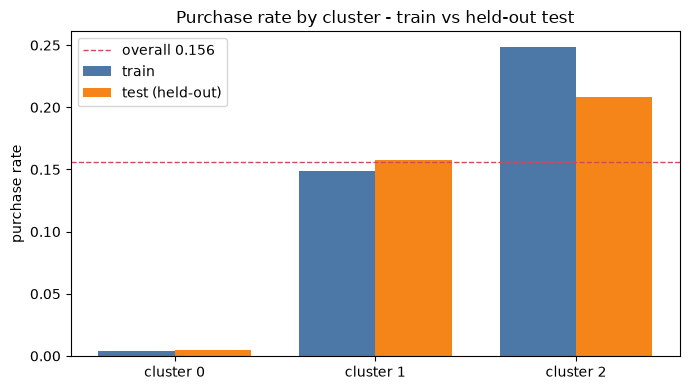

In [13]:
# ── 성능평가 ④: train/test 일반화 검증 (과적합 점검) ─────────────
# 군집을 train으로만 만들고, 학습에 안 쓴 test에서도 같은 구조·구매율이
# 재현되는지 본다. 재현되면 일반화된 것(과적합 아님).
TEST_SIZE = 0.25   # 검증용으로 떼어 둘 비율(25%)

# stratify=y: train/test의 구매율이 같도록 구매여부 비율을 맞춰 분할(층화).
Xtr_raw, Xte_raw, ytr, yte = train_test_split(
    X, y, test_size = TEST_SIZE, random_state = RANDOM_STATE, stratify = y)

# 누수 방지: 전처리(log+표준화)도 train에만 fit하고, test는 그 기준으로 '변환만' 한다.
# (test 정보가 학습에 새어들면 일반화 검증이 무의미해진다)
Xtr_log = Xtr_raw.copy(); Xtr_log[LOG_COLS] = np.log1p(Xtr_log[LOG_COLS])
Xte_log = Xte_raw.copy(); Xte_log[LOG_COLS] = np.log1p(Xte_log[LOG_COLS])
sc_gen = StandardScaler().fit(Xtr_log)
Z_tr, Z_te = sc_gen.transform(Xtr_log), sc_gen.transform(Xte_log)

# train으로만 군집 학습 → test는 predict로 '가장 가까운 중심'에 배정(학습에 미사용).
km_gen = KMeans(n_clusters = BEST_K, random_state = RANDOM_STATE, n_init = 10).fit(Z_tr)
lab_tr, lab_te = km_gen.labels_, km_gen.predict(Z_te)

# 비교 1: 실루엣이 train과 test에서 비슷한가(군집 경계가 특정 표본에 과적합 안 됐나)
sil_tr = silhouette_score(Z_tr, lab_tr)
sil_te = silhouette_score(Z_te, lab_te)

# 비교 2: 군집별 구매율·비중이 train ≈ test 인가
def _rate_size(lab, yv):
    """군집별 (구매율 평균, 세션 수)를 한 번에 반환하는 작은 도우미."""
    g = pd.DataFrame({'c': lab, 'y': yv.values}).groupby('c')['y']
    return g.mean(), g.size()
rt_tr, sz_tr = _rate_size(lab_tr, ytr)
rt_te, sz_te = _rate_size(lab_te, yte)
order = rt_tr.sort_values().index   # train 구매율 오름차순 = 즉시이탈 → 일반탐색 → 고관여

gen = pd.DataFrame({
    '라벨': ['즉시 이탈', '일반 탐색', '고관여'],
    'train_구매율': rt_tr[order].round(4).values,
    'test_구매율':  rt_te[order].round(4).values,
    'train_비중':   (sz_tr[order] / sz_tr.sum()).round(3).values,
    'test_비중':    (sz_te[order] / sz_te.sum()).round(3).values,
}, index = [f'cluster {c}' for c in order])

print('=== train/test 일반화 검증 (과적합 점검) ===')
print(f'Silhouette : train={sil_tr:.4f}  test={sil_te:.4f}  (차이 {abs(sil_tr - sil_te):.4f})')
print(f'전체 구매율: train={ytr.mean():.4f}  test={yte.mean():.4f}')
print('\n군집별 구매율·비중 (train 구매율 오름차순)')
print(gen.to_string())

# 시각화: 군집별 구매율을 train vs test 막대로 나란히(격차가 test에서도 유지되는가)
xpos = np.arange(BEST_K)
bar_w = 0.38   # 막대 두께(두 막대가 겹치지 않게)
plt.figure(figsize = (7, 4))
plt.bar(xpos - bar_w / 2, rt_tr[order].values, bar_w, label = 'train', color = '#4c78a8')
plt.bar(xpos + bar_w / 2, rt_te[order].values, bar_w, label = 'test (held-out)', color = '#f58518')
plt.axhline(y.mean(), color = '#d1495b', ls = '--', lw = 1, label = f'overall {y.mean():.3f}')
plt.xticks(xpos, [f'cluster {c}' for c in order])
plt.title('Purchase rate by cluster - train vs held-out test')
plt.ylabel('purchase rate'); plt.legend()
plt.tight_layout(); plt.show()

**해석 — 과적합 징후 없음.**
- **실루엣 train 0.319 ≈ test 0.319 (차이 0.0003).** test 점을 train이 만든 중심에 배정해도 군집 응집/분리가
  그대로 유지된다 — 군집 경계가 특정 표본에 과적합되지 않았다는 직접 증거.
- **군집별 구매율 격차가 test에서도 재현된다**: 즉시 이탈 0.4%(train) → 0.4%(test),
  일반 탐색 14.9% → 15.8%, 고관여 24.9% → 20.8%. 순서와 크기가 거의 그대로다
  (고관여는 ~4%p 낮아졌지만 표본 변동 수준이며 단조성은 유지).
- **군집 비중도 train ≈ test** (약 7.6% / 73.8% / 18.7% vs 7.5% / 73.0% / 19.5%) — 학습에 안 쓴 데이터에서도 같은 비율로 나뉜다.
- 7.3의 안정성(시드·부트스트랩 ARI ≈ 1)과 더해, **K=3 군집은 표본을 바꾸거나 새 데이터를 넣어도
  재현되는 일반화된 구조**다. 즉 과적합이 아니다.

## 8. (부록) K-Means 수렴 중간과정 — Lloyd 반복 시각화

K-Means가 *어떻게* 군집을 찾아가는지 단계별로 본다. 알고리즘은 두 단계를 번갈아 반복한다(Lloyd 알고리즘).

1. **할당(assign)**: 각 점을 가장 가까운 중심에 배정.
2. **갱신(update)**: 각 군집의 평균 위치로 중심을 이동.

K-Means 기본 초기화(**k-means++**, sklearn 기본값)에서 출발해 1 iteration씩 진행 상황을 기록한다.
군집은 *실제 분석과 동일하게 11차원 원공간에서* 수행하고, 한 번만 학습한 **고정 PCA**로 매 프레임을
같은 2D 평면에 투영해 서로 비교할 수 있게 한다. (프레임마다 군집 번호가 바뀌어 색이 섞이지 않도록,
각 프레임의 군집을 *최종 중심*에 매칭해 색을 통일했다.) 데이터가 작아 전 과정이 1~2초면 끝난다.

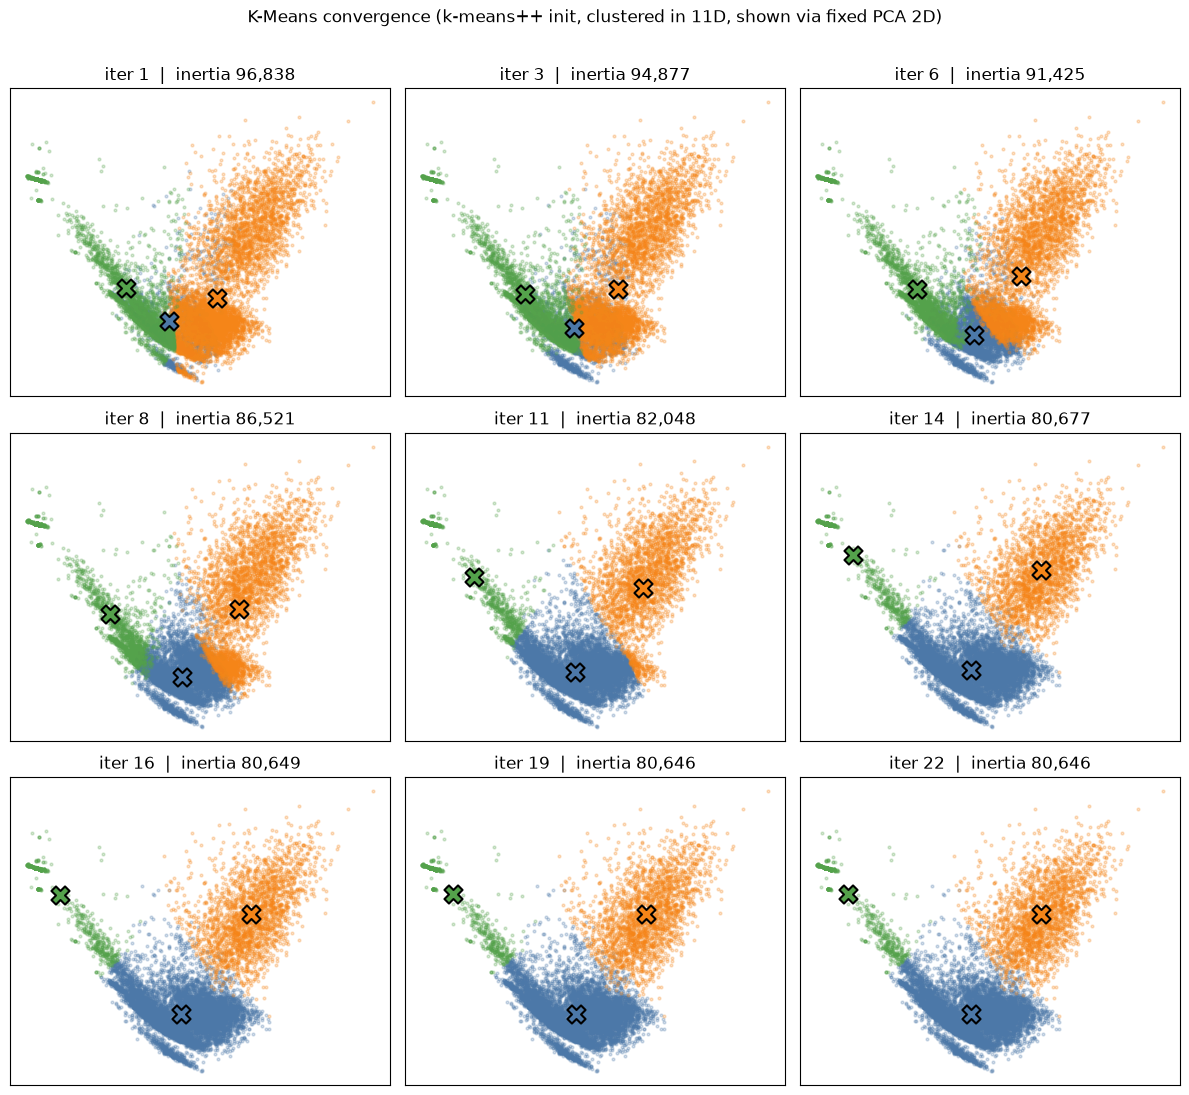

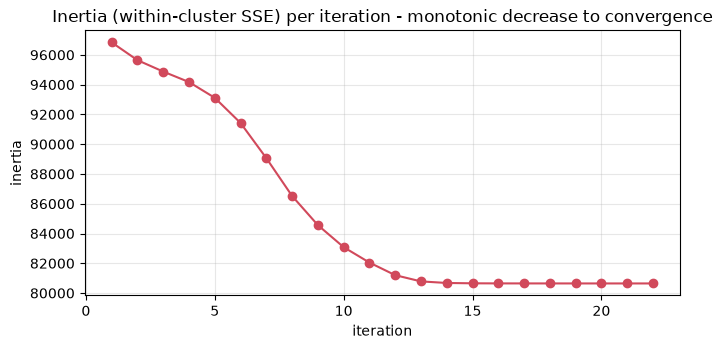

총 22 iteration 만에 수렴 (inertia 96,838 -> 80,646, 3장 n_init=10 결과와 동일)


In [14]:
# ── (부록) K-Means 수렴 과정 시각화 ──────────────────────────────
# K-Means가 군집을 찾아가는 '중간 과정'을 단계별로 보여준다.
# 한 번에 1 iteration씩만 돌려(max_iter=1) 중심이 이동하는 모습을 기록한다.
# §6(PCA 2D 시각화)에서 이미 fit한 pca와 좌표 coords를 그대로 재사용해 같은 평면에 그린다.

# k-means++ : 첫 중심을 똑똑하게 흩어 놓는 sklearn 기본 초기화 방법.
# 첫 호출은 k-means++로 시작하고, 이후엔 직전 결과의 중심을 넣어 1스텝씩 이어 붙인다.
MAX_ITERS = 30   # 안전 상한(보통 그 전에 수렴)
centers = 'k-means++'
frames, prev = [], None
for it in range(1, MAX_ITERS + 1):
    km = KMeans(n_clusters = BEST_K, init = centers, n_init = 1, max_iter = 1,
                random_state = RANDOM_STATE).fit(Z)
    frames.append({'it': it, 'labels': km.labels_.copy(),
                   'centers': km.cluster_centers_.copy(), 'inertia': km.inertia_})
    if prev is not None and np.allclose(prev, km.cluster_centers_):   # 중심이 안 움직이면 수렴
        break
    prev = centers = km.cluster_centers_

# iteration마다 군집 번호(0/1/2)가 임의로 뒤바뀔 수 있어 색이 깜빡인다.
# 각 프레임의 중심을 '최종 중심'에 1:1로 최적 매칭(linear_sum_assignment)해 색을 통일한다.
final_centers = frames[-1]['centers']
def align(fr):
    # 프레임 중심과 최종 중심 사이 거리표를 만들고, 총거리가 최소가 되게 짝짓는다.
    cost = np.linalg.norm(fr['centers'][:, None, :] - final_centers[None, :, :], axis = 2)
    row, col = linear_sum_assignment(cost)
    perm = np.empty(BEST_K, dtype = int)
    perm[row] = col
    return perm[fr['labels']], perm   # (색 통일된 라벨, 군집번호 변환표)

# 프레임이 많으면(>9) 처음~끝을 고르게 9장만 골라 3x3 격자로 보여준다.
MAX_PANELS = 9
if len(frames) <= MAX_PANELS:
    show = frames
else:
    idx = np.unique(np.linspace(0, len(frames) - 1, MAX_PANELS).astype(int))
    show = [frames[i] for i in idx]

COL = ['#4c78a8', '#f58518', '#54a24b']   # 군집 0/1/2 색
ncol = 3
nrow = int(np.ceil(len(show) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize = (12, 3.6 * nrow))
for ax, fr in zip(axes.ravel(), show):
    al, perm = align(fr)
    for c in range(BEST_K):                 # 점: 군집별 색으로 흩뿌리기
        m = al == c
        ax.scatter(coords[m, 0], coords[m, 1], s = 4, alpha = 0.25, color = COL[c])
    cen2 = pca.transform(fr['centers'])     # 중심(11D)을 같은 PCA로 2D에 투영
    for k in range(BEST_K):
        ax.scatter(cen2[k, 0], cen2[k, 1], color = COL[perm[k]], marker = 'X',
                   s = 170, edgecolor = 'black', linewidth = 1.5, zorder = 5)
    ax.set_title(f"iter {fr['it']}  |  inertia {fr['inertia']:,.0f}")
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.ravel()[len(show):]:         # 남는 빈 칸 숨기기
    ax.axis('off')
fig.suptitle('K-Means convergence (k-means++ init, clustered in 11D, shown via fixed PCA 2D)', y = 1.01)
plt.tight_layout()
plt.show()

# inertia(군집내 거리합)가 반복마다 줄어 평평해지는 '수렴 곡선'
plt.figure(figsize = (7, 3.6))
its = [f['it'] for f in frames]
ins = [f['inertia'] for f in frames]
plt.plot(its, ins, marker = 'o', color = '#d1495b')
plt.title('Inertia (within-cluster SSE) per iteration - monotonic decrease to convergence')
plt.xlabel('iteration'); plt.ylabel('inertia'); plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

print(f'총 {len(frames)} iteration 만에 수렴 '
      f'(inertia {frames[0]["inertia"]:,.0f} -> {frames[-1]["inertia"]:,.0f}, '
      f'3장 n_init=10 결과와 동일)')

**해석.**
- **중심(✕)이 매 iteration마다 군집 평균으로 이동**하며 점들의 색(소속 군집)이 안정된다.
  초반 몇 번에서 크게 움직인 뒤 점점 미세 조정으로 바뀌는 게 보인다.
- **inertia 곡선이 가파르게 떨어진 뒤 평평**해지는 지점이 수렴이다. K-Means는 매 iteration마다 inertia를
  절대 늘리지 않으므로(수렴 보장) 곡선은 항상 우하향하다 멈춘다.
- 약 20여 회 반복 만에 **3장 `n_init=10` 결과와 동일한 inertia(80,646)** 로 수렴한다 —
  *즉시 이탈 / 일반 탐색 / 고관여* 세 군집을 그대로 다시 찾아낸다. 7.3의 안정성(시드 ARI = 1.000)을
  *과정*으로 보여주는 셈이다. (단, 무작위 단일 초기화는 더 나쁜 국소최솟값에 빠질 수 있어 `n_init=10`으로
  여러 번 시도하는 것이며, 여기서는 기본 초기화 k-means++가 좋은 해로 안정적으로 수렴한다.)
- 이 그림의 군집은 11차원에서 수행하고 2D로 투영한 것이라(분산 54%) 평면상 경계가 겹쳐 보일 수 있다.
  실제 분리는 6장 PCA 해석과 마찬가지로 원공간 기준이다.

## 9. 산출물 저장 + 결론

군집 라벨을 CSV로 저장해 다른 분석에서 재사용할 수 있게 한다.


In [15]:
# ── 산출물 저장 ──────────────────────────────────────────────────
# 군집 결과를 CSV로 남겨 다른 분석·보고서에서 재사용할 수 있게 한다.
# 노트북을 clustering 폴더에서 실행하든 저장소 루트에서 실행하든 같은 위치에 저장되도록 분기.
out_dir = Path.cwd() / 'csv' if (Path.cwd().name == 'clustering') else Path.cwd() / 'models' / 'clustering' / 'csv'
out_dir.mkdir(parents = True, exist_ok = True)   # 폴더 없으면 생성

# (1) 세션별 군집번호 + 구매여부   (2) 군집별 프로파일 요약표
cluster_assignment = profile[['cluster', 'Revenue']].copy()
cluster_assignment.to_csv(out_dir / 'cluster_assignment.csv', index = False)
profile_table.round(4).to_csv(out_dir / 'cluster_profile.csv')

print(f'저장: {out_dir / "cluster_assignment.csv"}')
print(f'저장: {out_dir / "cluster_profile.csv"}')

저장: C:\Users\HANSUNG\shopper-prediction\models\clustering\csv\cluster_assignment.csv
저장: C:\Users\HANSUNG\shopper-prediction\models\clustering\csv\cluster_profile.csv


### 결론 — 지도학습 3종과의 연결

- 군집화는 **행동 변수만으로** 방문자를 3개 유형(즉시이탈 / 일반탐색 / 고관여)으로 자동 분리했고,
  학습에 쓰지 않은 실제 구매율이 **0.4% → 15% → 24%** 로 단조 상승해 군집이 구매 성향과 잘 맞음을 검증했다.
- 이는 DT/RF/KNN 세 모델이 공통으로 `ProductRelated_Duration`·`ProductRelated`(세션 깊이) 변수에
  크게 의존한 결과와 **같은 신호를 가리킨다**: 예측 모델이 중요하게 본 축이 곧 군집을 가르는 축이다.
- 실무 함의: **고관여 군집**은 리타게팅·혜택 집중 대상, **일반 탐색 군집**은 구매 전환 유도(전환률 개선 여지가
  가장 큰 다수), **즉시 이탈 군집**은 랜딩/유입 품질 개선 대상으로 차등 전략을 세울 수 있다.
